# RESEARCH QUESTION
### "Which degree fields offer fresh graduates the best combination of salary and job security in Singapore?"
- Which degree fields have the highest starting salaries and employment rates?
- How resilient are different fields during economic downturns (e.g., 2020 COVID)?

### Import Libraries

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


C:\Users\MZafr\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df1 = pd.read_csv('CA2 Datasets\(1) graduate employment survey modified.csv')
df2 = pd.read_csv('CA2 Datasets\(2) graduate employment survey modified .csv')
df3 = pd.read_csv('CA2 Datasets/employed_15_sex_edu_age_yr.csv')
df4 = pd.read_excel('CA2 Datasets/LFR2023_SectionD.xlsx', sheet_name='D1', skiprows=6)

## Data Cleaning

In [3]:
display(df1.head())
print(df1.info())

,year,university,school,degree,Key
0,2013,Nanyang Technological University,College of Business (Nanyang Business School),Accountancy and Business,1
1,2013,Nanyang Technological University,College of Business (Nanyang Business School),Accountancy (3-yr direct Honours Programme),2
2,2013,Nanyang Technological University,College of Business (Nanyang Business School),Business (3-yr direct Honours Programme),3
3,2013,Nanyang Technological University,College of Business (Nanyang Business School),Business and Computing,4
4,2013,Nanyang Technological University,College of Engineering,Aerospace Engineering,5


<class 'pandas.DataFrame'>
RangeIndex: 5135 entries, 0 to 5134
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   year        5135 non-null   str  
 1   university  5135 non-null   str  
 2   school      5135 non-null   str  
 3   degree      5135 non-null   str  
 4   Key         5135 non-null   int64
dtypes: int64(1), str(4)
memory usage: 722.7 KB
None


In [4]:
display(df2.head())
print(df2.info())

,employment_rate_overall,employment_rate_ft_perm,basic_monthly_mean,basic_monthly_median,gross_monthly_mean,gross_monthly_median,gross_mthly_25_percentile,gross_mthly_75_percentile,gross_monthly_mean.1,gross_monthly_median.1,...,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Key
0,97.4,96.1,3701,3200,3727,3350,2900,4000,3727,3350,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,97.1,95.7,2850,2700,2938,2700,2700,2900,2938,2700,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
2,90.9,85.7,3053,3000,3214,3000,2700,3500,3214,3000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,87.5,87.5,3557,3400,3615,3400,3000,4100,3615,3400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
4,95.3,95.3,3494,3500,3536,3500,3100,3816,3536,3500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5


<class 'pandas.DataFrame'>
RangeIndex: 5135 entries, 0 to 5134
Data columns (total 48 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   employment_rate_overall      5027 non-null   str    
 1   employment_rate_ft_perm      5027 non-null   str    
 2   basic_monthly_mean           5027 non-null   str    
 3   basic_monthly_median         5027 non-null   str    
 4   gross_monthly_mean           5027 non-null   str    
 5   gross_monthly_median         5027 non-null   str    
 6   gross_mthly_25_percentile    5027 non-null   str    
 7   gross_mthly_75_percentile    5027 non-null   str    
 8   gross_monthly_mean.1         5027 non-null   str    
 9   gross_monthly_median.1       5027 non-null   str    
 10  gross_mthly_25_percentile.1  5027 non-null   str    
 11  gross_mthly_75_percentile.1  5027 non-null   str    
 12  Unnamed: 12                  0 non-null      float64
 13  Unnamed: 13                  

In [5]:
# =============================================================================
# DATA CLEANING CODE FOR PDAS CA2 PROJECT (VERSION 2)
# - Fixes footnote suffixes (**, #, ^, etc.)
# - Standardizes & vs 'and', capitalization
# - Fixes SMU naming inconsistencies across years
# Add this to your notebook after loading df1 and df2
# =============================================================================

import pandas as pd
import numpy as np
import re

# =============================================================================
# DEGREE NAME CLEANING FUNCTION (UPDATED)
# =============================================================================

def clean_degree_name(degree):
    if pd.isna(degree):
        return degree
    
    d = str(degree).strip()
    
    # Remove trailing footnote markers (**, #, ^, ##, ###, ^^, combinations)
    d = re.sub(r'[\s]*[\*\#\^]+[\s\*\#\^]*$', '', d).strip()
    
    # Remove "(4-year programme)" and "(4-years programme)" for all degrees
    d = re.sub(r'\s*\(4-years? programme\)', '', d)
    
    # Standardize "(Cum Laude and above)" to "Cum Laude and above"
    d = d.replace('(Cum Laude and above)', 'Cum Laude and above')
    
    # Standardize & to "and"
    d = d.replace(' & ', ' and ')
    
    # Fix capitalization: "And" -> "and", "Of" -> "of"
    d = re.sub(r'\bAnd\b', 'and', d)
    d = re.sub(r'\bOf\b', 'of', d)
    
    # Standardize Bachelor of Medicine variations (remove MBBS suffix etc)
    d = re.sub(r'Bachelor of Medicine and Bachelor of Surgery.*', 'Bachelor of Medicine and Bachelor of Surgery', d)
    
    # Standardize Bachelor of Laws variations (L.L.B -> LLB)
    d = d.replace('(L.L.B)', '(LLB)')
    
    # Fix any double spaces
    d = re.sub(r'\s+', ' ', d).strip()
    
    return d


# =============================================================================
# APPLY CLEANING TO df1
# =============================================================================

# Clean the degree names BEFORE merging
df1['degree'] = df1['degree'].apply(clean_degree_name)

print(f"Unique degrees after cleaning: {df1['degree'].nunique()}")


# =============================================================================
# MERGE AND CLEAN COMBINED DATA
# =============================================================================

# Merge on Key
grad = df1.merge(df2, on='Key')

# Keep only useful columns
cols_to_keep = [
    'year', 'university', 'school', 'degree',
    'employment_rate_overall', 'employment_rate_ft_perm',
    'basic_monthly_mean', 'basic_monthly_median',
    'gross_monthly_mean', 'gross_monthly_median',
    'gross_mthly_25_percentile', 'gross_mthly_75_percentile'
]
grad = grad[cols_to_keep]

# Remove the header row that's mixed into data
grad = grad[grad['year'] != 'year']

# Replace 'na' strings with NaN
grad = grad.replace('na', np.nan)

# Convert to proper data types BEFORE filtering
grad['year'] = pd.to_numeric(grad['year'], errors='coerce')
numeric_cols = [
    'employment_rate_overall', 'employment_rate_ft_perm',
    'basic_monthly_mean', 'basic_monthly_median',
    'gross_monthly_mean', 'gross_monthly_median',
    'gross_mthly_25_percentile', 'gross_mthly_75_percentile'
]
for col in numeric_cols:
    grad[col] = pd.to_numeric(grad[col], errors='coerce')


# =============================================================================
# REMOVE BAD DATA AND DUPLICATES
# =============================================================================

# Remove rows with obviously corrupted salary data (< 1000 is suspicious for SG grad salaries)
grad = grad[grad['gross_monthly_median'] >= 1000]

# Drop rows with any remaining NaN values
grad = grad.dropna()

# Convert year to int (after dropna)
grad['year'] = grad['year'].astype(int)

# Remove duplicate rows (same year, university, school, degree)
# Keep the first occurrence
grad = grad.drop_duplicates(subset=['year', 'university', 'school', 'degree'], keep='first')

# Reset index
grad = grad.reset_index(drop=True)


# =============================================================================
# VERIFY THE RESULTS
# =============================================================================

print("\n" + "="*60)
print("CLEANING COMPLETE!")
print("="*60)
print(f"Final dataset shape: {grad.shape}")
print(f"Unique degrees: {grad['degree'].nunique()}")
print(f"Year range: {grad['year'].min()} - {grad['year'].max()}")
print(f"Universities: {grad['university'].nunique()}")
print(f"\nSalary range: ${grad['gross_monthly_median'].min():.0f} - ${grad['gross_monthly_median'].max():.0f}")
print(f"Employment rate range: {grad['employment_rate_overall'].min():.1f}% - {grad['employment_rate_overall'].max():.1f}%")

Unique degrees after cleaning: 239

CLEANING COMPLETE!
Final dataset shape: (1141, 12)
Unique degrees: 210
Year range: 2013 - 2022
Universities: 5

Salary range: $1800 - $6600
Employment rate range: 66.7% - 100.0%


In [6]:
display(df3.head())
print(df3.info())

,year,sex,age,edu_1,employed
0,2010,male,15-19,primary_and_below,200
1,2010,male,20-24,primary_and_below,600
2,2010,male,25-29,primary_and_below,1000
3,2010,male,30-34,primary_and_below,2800
4,2010,male,35-39,primary_and_below,6400


<class 'pandas.DataFrame'>
RangeIndex: 2160 entries, 0 to 2159
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   year      2160 non-null   int64
 1   sex       2160 non-null   str  
 2   age       2160 non-null   str  
 3   edu_1     2160 non-null   str  
 4   employed  2160 non-null   str  
dtypes: int64(1), str(4)
memory usage: 144.1 KB
None


In [7]:
print(df3['employed'].unique()[:20])  # Check for any weird values like '-' or 'na'
print(df3[df3['employed'] == '-'])

<ArrowStringArray>
[  '200',   '600',  '1000',  '2800',  '6400', '13500', '25300', '30600',
 '19800', '10700',  '9500',  '1600',  '2300',  '3000',  '4200',  '7400',
 '12000', '20200', '22400', '12100']
Length: 20, dtype: str
      year     sex    age   edu_1 employed
60    2010    male  15-19  degree        -
132   2010  female  15-19  degree        -
204   2011    male  15-19  degree        -
276   2011  female  15-19  degree        -
348   2012    male  15-19  degree        -
420   2012  female  15-19  degree        -
492   2013    male  15-19  degree        -
564   2013  female  15-19  degree        -
636   2014    male  15-19  degree        -
708   2014  female  15-19  degree        -
780   2015    male  15-19  degree        -
852   2015  female  15-19  degree        -
924   2016    male  15-19  degree        -
1068  2017    male  15-19  degree        -
1140  2017  female  15-19  degree        -
1212  2018    male  15-19  degree        -
1284  2018  female  15-19  degree        -
1

In [8]:
# Convert '-' to NaN and make the column numeric
df3['employed'] = pd.to_numeric(df3['employed'], errors='coerce')
df3 = df3.dropna()

# Verify it worked
print(df3.info())
print("-------------")
print(df3.head())

<class 'pandas.DataFrame'>
Index: 2131 entries, 0 to 2159
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      2131 non-null   int64  
 1   sex       2131 non-null   str    
 2   age       2131 non-null   str    
 3   edu_1     2131 non-null   str    
 4   employed  2131 non-null   float64
dtypes: float64(1), int64(1), str(3)
memory usage: 150.5 KB
None
-------------
   year   sex    age              edu_1  employed
0  2010  male  15-19  primary_and_below     200.0
1  2010  male  20-24  primary_and_below     600.0
2  2010  male  25-29  primary_and_below    1000.0
3  2010  male  30-34  primary_and_below    2800.0
4  2010  male  35-39  primary_and_below    6400.0


In [9]:
display(df4.head())
print(df4.info())

,Unnamed: 0,Unnamed: 1,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Total,Total,2056.1,2103.5,2147.8,2165.3,2175.3,2203.7,2230.4,2222.6,2286.5,2350.4,2352.3
1,NaN,Managers & Administrators (Including Working P...,360.5,351.2,355.8,337.5,348.8,341.6,364.9,368.3,377.7,407.7,369.9
2,NaN,Professionals,371.9,383.3,404.1,419.8,437.6,449.2,469.4,504.2,577.5,600.9,620.6
3,NaN,Associate Professionals & Technicians,359.5,391.5,408.3,438.1,436.2,465.0,467.9,458.2,465.8,485.7,482.5
4,NaN,Clerical Support Workers,271.8,268.4,267.7,244.9,247.9,241.0,237.2,215.6,223.4,211.8,207.8


<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8 non-null      str    
 1   Unnamed: 1  30 non-null     str    
 2   2013        30 non-null     float64
 3   2014        30 non-null     float64
 4   2015        30 non-null     float64
 5   2016        30 non-null     float64
 6   2017        30 non-null     float64
 7   2018        30 non-null     float64
 8   2019        30 non-null     float64
 9   2020        30 non-null     float64
 10  2021        30 non-null     float64
 11  2022        30 non-null     float64
 12  2023        30 non-null     float64
dtypes: float64(11), str(2)
memory usage: 5.0 KB
None


In [10]:
# Rename the first two columns
df4 = df4.rename(columns={
    'Unnamed: 0': 'Category',
    'Unnamed: 1': 'Occupation'
})

# Check the result
print(df4[['Category','Occupation',2013]].tail(20))

                                             Category  \
16                                                NaN   
17                                                NaN   
18                                                NaN   
19                                                NaN   
20                                             Female   
21                                                NaN   
22                                                NaN   
23                                                NaN   
24                                                NaN   
25                                                NaN   
26                                                NaN   
27                                                NaN   
28                                                NaN   
29                                                NaN   
30                                                NaN   
31  Source: Comprehensive Labour Force Survey, Man...   
32                             

In [11]:
# See all unique values in the Category column to understand the structure
print(f'{df4['Category'].unique()}\n')
print(df4['Occupation'].unique())

<ArrowStringArray>
[                                                                                                                                                                                                                                                 'Total',
                                                                                                                                                                                                                                                      nan,
                                                                                                                                                                                                                                                   'Male',
                                                                                                                                                                                                                                    

In [12]:
# 1. Remove the footer rows (source notes, etc.)
df4 = df4[df4['Occupation'].notna()]  # Keep only rows with actual occupation data

# 2. Forward fill the Category column (fills NaN with previous value)
df4['Category'] = df4['Category'].ffill() 

df4_total = df4[df4['Category'] == 'Total'].copy()
df4_total = df4_total.drop(columns=['Category'])
df4_total = df4_total.reset_index(drop=True)

print("=== DF4_TOTAL (Occupation Data - Totals Only) ===")
print(df4_total)


=== DF4_TOTAL (Occupation Data - Totals Only) ===
                                          Occupation    2013    2014    2015  \
0                                              Total  2056.1  2103.5  2147.8   
1  Managers & Administrators (Including Working P...   360.5   351.2   355.8   
2                                      Professionals   371.9   383.3   404.1   
3              Associate Professionals & Technicians   359.5   391.5   408.3   
4                           Clerical Support Workers   271.8   268.4   267.7   
5                            Service & Sales Workers   244.7   244.3   251.6   
6                 Craftsmen & Related Trades Workers    82.2    82.2    83.9   
7             Plant & Machine Operators & Assemblers   146.9   145.9   146.1   
8              Cleaners, Labourers & Related Workers   150.2   166.0   160.3   
9                                             Others    68.7    70.8    70.0   

     2016    2017    2018    2019    2020    2021    2022    2023  
0

In [13]:
print("\n" + "="*50)
print("DATA CLEANING COMPLETE")
print("="*50)
print(f"grad     : {grad.shape[0]} rows - Graduate salaries & employment (2012-2022)")
print(f"df3      : {df3.shape[0]} rows - Employment by education/age (2010-2024)")
print(f"df4_total: {df4_total.shape[0]} rows - Employment by occupation (2013-2023)")


DATA CLEANING COMPLETE
grad     : 1141 rows - Graduate salaries & employment (2012-2022)
df3      : 2131 rows - Employment by education/age (2010-2024)
df4_total: 10 rows - Employment by occupation (2013-2023)


# Data Visualisations

### Chart 1: Workforce Context (df3 + df4)

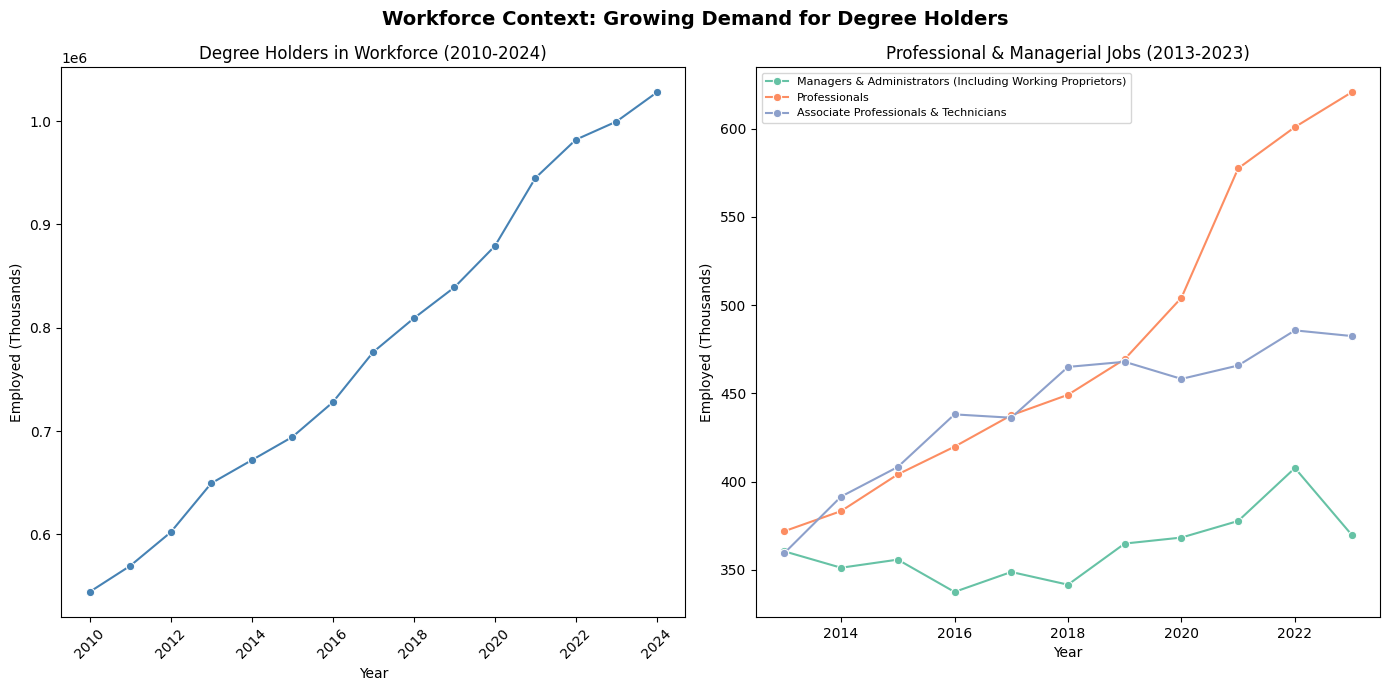

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# LEFT: Degree Holders (df3)
degree_holders = df3[df3['edu_1'] == 'degree']
degree_by_year = degree_holders.groupby('year')['employed'].sum().reset_index()

sns.lineplot(
    data=degree_by_year,
    x='year',
    y='employed',
    marker='o',
    color='steelblue',
    ax=axes[0]
)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Employed (Millions)')
axes[0].set_title('Degree Holders in Workforce (2010-2024)')
axes[0].tick_params(axis='x', rotation=45)

# RIGHT: Professional Jobs (df4)
key_occupations = [
    'Professionals',
    'Managers & Administrators (Including Working Proprietors)',
    'Associate Professionals & Technicians'
]

df4_filtered = df4_total[df4_total['Occupation'].isin(key_occupations)].copy()

df4_long = df4_filtered.melt(
    id_vars=['Occupation'],
    var_name='Year',
    value_name='Employed_Thousands'
)
df4_long['Year'] = df4_long['Year'].astype(int)

sns.lineplot(
    data=df4_long,
    x='Year',
    y='Employed_Thousands',
    hue='Occupation',
    marker='o',
    ax=axes[1],
    palette = 'Set2'
)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Employed (Thousands)')
axes[1].set_title('Professional & Managerial Jobs (2013-2023)')
axes[1].legend(fontsize=8, loc='upper left')

fig.suptitle('Workforce Context: Growing Demand for Degree Holders', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Chart 1 Insights
shows that the increase of degree holders in workforce from 2010 to 2024 roughly follows a linear path from XX thousands to X thousands suggesting an ever present demand for degree holders in the workforce. However from 2022 to 2024, managerial workers experienced a significant lay offs which may signal a lower need for management due to the covid promoting remote work. 


### Chart 2: Top 10 Highest Paying Degrees

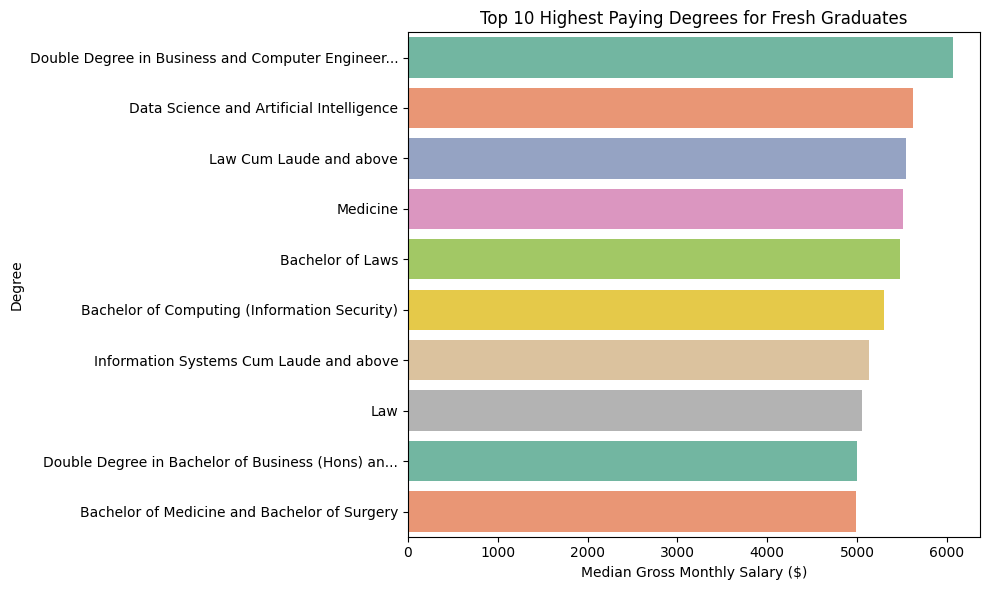

In [15]:
# Group by degree and calculate mean salary, then get top 10
top_salary = grad.groupby('degree')['gross_monthly_median'].mean().sort_values(ascending=False).head(10)

# Shorten long degree names for display
def shorten_degree(name, max_len=50):
    if len(name) > max_len:
        return name[:max_len-3] + '...'
    return name

top_salary = top_salary.rename(index=shorten_degree)

# Create figure
plt.figure(figsize=(10, 6))

# Create horizontal bar chart
sns.barplot(x=top_salary.values, y=top_salary.index, palette='Set2', hue=top_salary.index)

# Labels and title
plt.xlabel('Median Gross Monthly Salary ($)')
plt.ylabel('Degree')
plt.title('Top 10 Highest Paying Degrees for Fresh Graduates')

# Make it look nicer
plt.tight_layout()
plt.show()

### Chart 2 Insights
Law, medicine and computing degrees dominate the top with computing with computing appearing the most in the top 10, suggesting high demand for the field and since, it can be done remotely, it can be resilient against economic hardship. With double degrees appearing too, it can be worth it to consider taking 2 degrees at once.

### Chart 3: Bottom 10 Degrees by Employment Rate

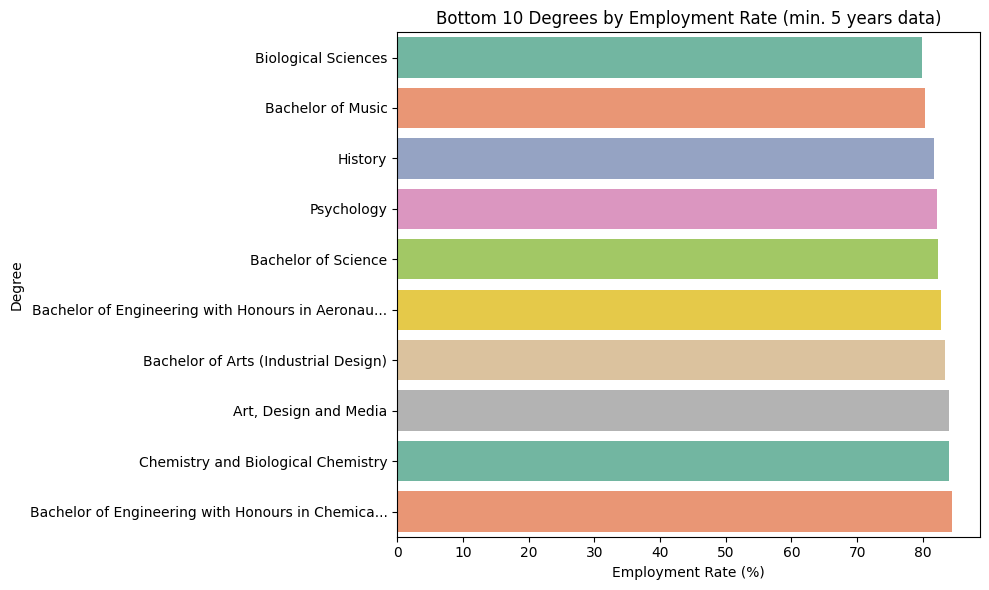

In [16]:
employment_stats = grad.groupby('degree').agg({
    'employment_rate_overall': 'mean',
    'year': 'count'
}).rename(columns={'year': 'data_points'})

reliable_degrees = employment_stats[employment_stats['data_points'] >= 5]
bottom_employment = reliable_degrees['employment_rate_overall'].sort_values(ascending=True).head(10)

# Shorten long degree names for display
bottom_employment = bottom_employment.rename(index=shorten_degree)

plt.figure(figsize=(10, 6))
sns.barplot(x=bottom_employment.values, y=bottom_employment.index, hue=bottom_employment.index, palette='Set2', legend=False)

plt.xlabel('Employment Rate (%)')
plt.ylabel('Degree')
plt.title('Bottom 10 Degrees by Employment Rate (min. 5 years data)')

plt.tight_layout()
plt.show()

### Chart 3 Insights
the arts and pure science degrees face lower employment rate with both appearing to be in the least demand. Showcasing how it can be risky to pursue pure science or arts and a likely need to pivot to another field to gain some success.

### Chart 4: Salary vs Employment by School (COLORS + LABELS)

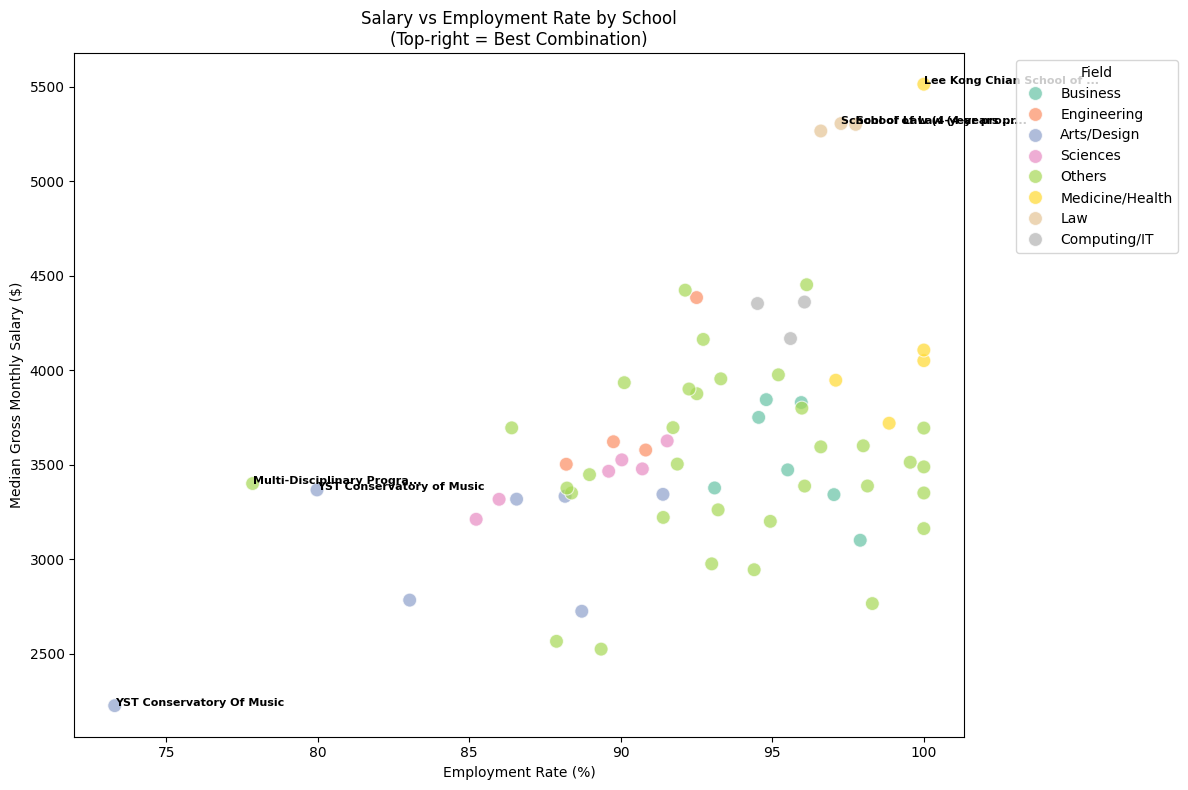

In [17]:
# Group by school
by_school = grad.groupby('school').agg({
    'gross_monthly_median': 'mean',
    'employment_rate_overall': 'mean'
}).reset_index()

# Create field categories
def categorize_school(school):
    school_lower = school.lower()
    if 'law' in school_lower:
        return 'Law'
    elif 'medic' in school_lower or 'dentist' in school_lower or 'nursing' in school_lower:
        return 'Medicine/Health'
    elif 'business' in school_lower or 'accountancy' in school_lower:
        return 'Business'
    elif 'engineering' in school_lower:
        return 'Engineering'
    elif 'computing' in school_lower or 'information' in school_lower:
        return 'Computing/IT'
    elif 'art' in school_lower or 'design' in school_lower or 'music' in school_lower:
        return 'Arts/Design'
    elif 'science' in school_lower:
        return 'Sciences'
    else:
        return 'Others'

by_school['field'] = by_school['school'].apply(categorize_school)
grad['field'] = grad['school'].apply(categorize_school)

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=by_school,
    x='employment_rate_overall',
    y='gross_monthly_median',
    hue='field',
    s=100,
    alpha=0.7,
    palette='Set2'
)

# Label only top 3 salary and bottom 3 employment
top_salary = by_school.nlargest(3, 'gross_monthly_median')
low_employment = by_school.nsmallest(3, 'employment_rate_overall')
to_label = pd.concat([top_salary, low_employment]).drop_duplicates()

for i, row in to_label.iterrows():
    label = row['school'][:25] + '...' if len(row['school']) > 25 else row['school']
    plt.annotate(
        label,
        (row['employment_rate_overall'], row['gross_monthly_median']),
        fontsize=8,
        fontweight='bold'
    )

plt.xlabel('Employment Rate (%)')
plt.ylabel('Median Gross Monthly Salary ($)')
plt.title('Salary vs Employment Rate by School\n(Top-right = Best Combination)')
plt.legend(title='Field', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Chart 4 Insights
Medicine and law degrees are very sought after displayed by how the salary and employment are much higher than the other fields with computing middling in demand and arts facing much lower demand with a lower salary and employment rate

### Chart 5: Year-over-Year Salary Change by Field (%)

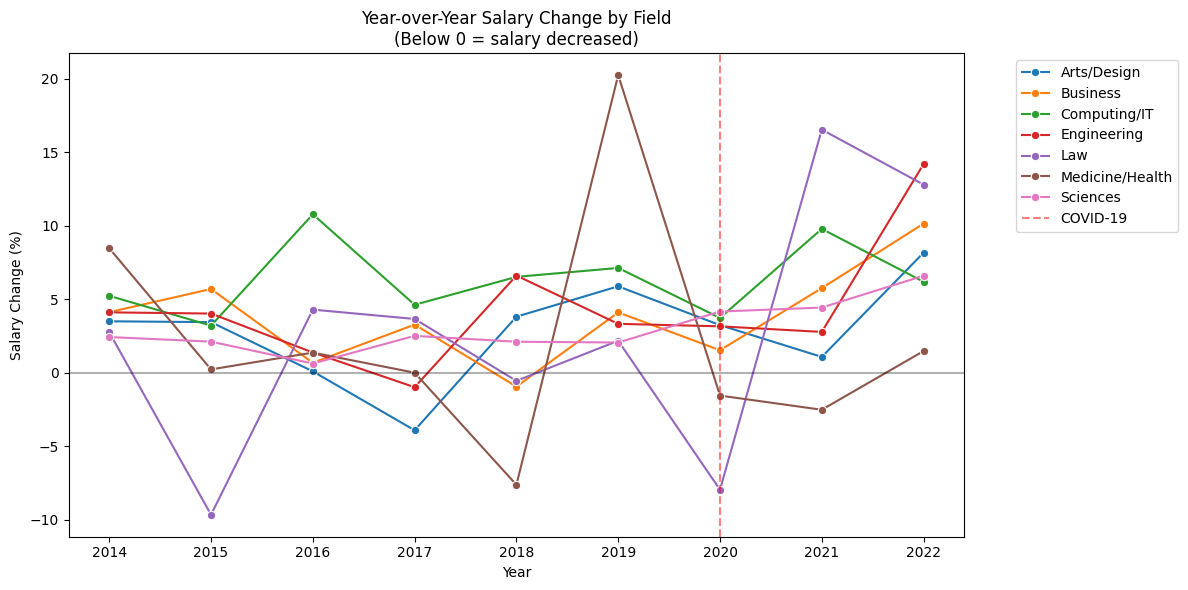

In [18]:
# Group by year and field
salary_by_year = grad.groupby(['year', 'field'])['gross_monthly_median'].mean().reset_index()
salary_by_year = salary_by_year[(salary_by_year['field'] != 'Others') & (salary_by_year['year'] >= 2013)]

# Calculate percentage change
salary_by_year['pct_change'] = salary_by_year.groupby('field')['gross_monthly_median'].pct_change() * 100

# Remove first year (no previous year to compare)
salary_change = salary_by_year[salary_by_year['year'] >= 2014]

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=salary_change,
    x='year',
    y='pct_change',
    hue='field',
    marker='o',
    palette='tab10'
)

plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.axvline(x=2020, color='red', linestyle='--', alpha=0.5, label='COVID-19')

plt.xlabel('Year')
plt.ylabel('Salary Change (%)')
plt.title('Year-over-Year Salary Change by Field\n(Below 0 = salary decreased)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Chart 5 insights
From 2019 to 2020, many degrees experienced a sudden decrease in the rate change of salary with law and medicine decreasing in salary overall after 2020, most recovered except medicine (might be an action to bolster the medical workforce with an influx of workers) which saw a decrease in salary from 2020 to 2021 but computing and law grew strongly in demand post-covid.

### Chart 6: Employment Rate Trends by Field

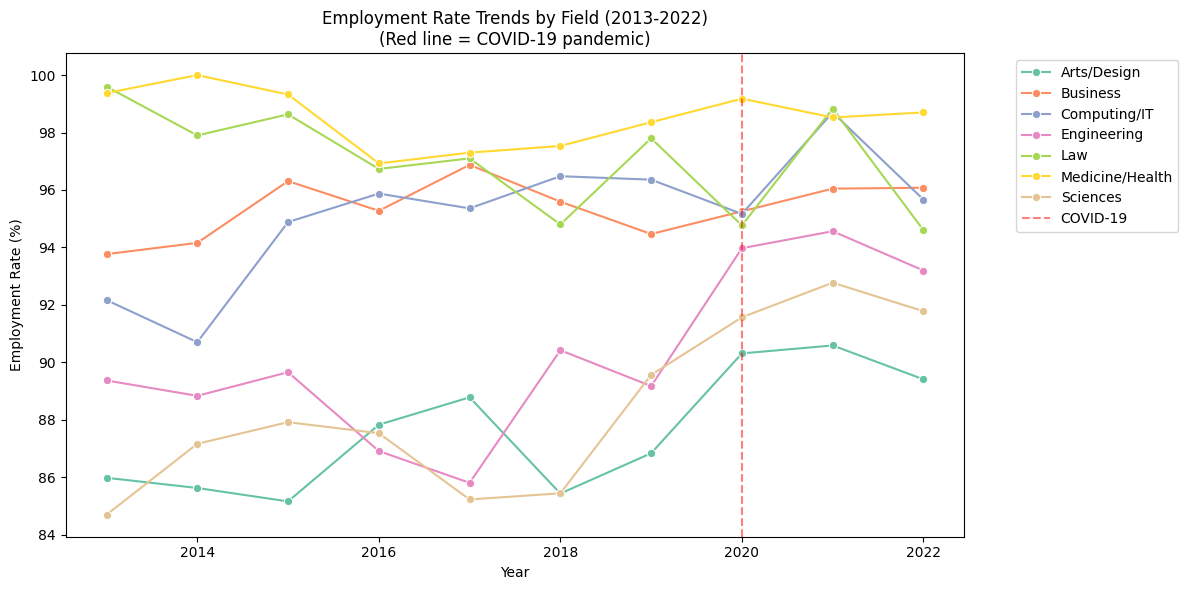

In [19]:
# Group by year and field
emp_trend = grad.groupby(['year', 'field'])['employment_rate_overall'].mean().reset_index()

# Remove 'Others' and start from 2013
emp_trend = emp_trend[(emp_trend['field'] != 'Others') & (emp_trend['year'] >= 2013)]

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=emp_trend,
    x='year',
    y='employment_rate_overall',
    hue='field',
    marker='o',
    palette='Set2'
)

# Add vertical line for COVID
plt.axvline(x=2020, color='red', linestyle='--', alpha=0.5, label='COVID-19')

plt.xlabel('Year')
plt.ylabel('Employment Rate (%)')
plt.title('Employment Rate Trends by Field (2013-2022)\n(Red line = COVID-19 pandemic)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Chart 6 Insights
Many fields experience a decrease rate of change with medicine decreasing in employment rate from 2020 to 2021 while law and computing grew in demand and reached record highs but were dipped in demand soon after but not greatly which can also be said for the other fields except medicine.

### Chart 7: Salary Distribution

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=grad,
    x='gross_monthly_median',
    kde=True,
    bins=30,
    color='steelblue'
)

median_val = grad['gross_monthly_median'].median()
mean_val = grad['gross_monthly_median'].mean()

plt.axvline(median_val, color='red', linestyle='--', label=f'Median: ${median_val:.0f}')
plt.axvline(mean_val, color='orange', linestyle='--', label=f'Mean: ${mean_val:.0f}')

plt.xlabel('Median Gross Monthly Salary ($)')
plt.ylabel('Count')
plt.title('Distribution of Graduate Starting Salaries')
plt.legend()

plt.tight_layout()
plt.show()

NameError: name 'grad_clean' is not defined

<Figure size 1000x600 with 0 Axes>

### Chart 7 Insights
peaks around $3500 being negatively skewed due to very in demand degrees like law and medicine pulling the mean above the median

# Conclusion